# 1. Dataset Setup

Load the battery cycle files and check the dataset structure.

In [1]:
from pathlib import Path

DATA_DIR = Path("/content")

parquet_files = sorted(DATA_DIR.glob("Qtzl_Cycle_*.parquet"))

# Expected number of cycles files.
EXPECTED_FILE_COUNT = 410

print("Total number of Parquet files:", len(parquet_files))
print("First file:", parquet_files[0].name)
print("Last file:", parquet_files[-1].name)

if len(parquet_files) == EXPECTED_FILE_COUNT:
    print("Dataset file count check: PASSED")
else:
    print("Dataset file count check: WARNING")
    print(
        f"Expected {EXPECTED_FILE_COUNT} files, "
        f"but found {len(parquet_files)} files."
    )

Total number of Parquet files: 410
First file: Qtzl_Cycle_001_Capacity_check_partial_data.parquet
Last file: Qtzl_Cycle_410_WLTP.parquet
Dataset file count check: PASSED


## Dataset Structure

Inspect the columns and check that all cycle files have the same structure.

In [ ]:
import pyarrow.parquet as pq

sample_file = parquet_files[0]

parquet_file = pq.ParquetFile(sample_file)

column_names = parquet_file.schema.names

cell_voltage_columns = [
    column for column in column_names
    if column.startswith("Voltage_Cell_")
]

cell_temperature_columns = [
    column for column in column_names
    if column.startswith("Temperature_Cell_")
]

branch_current_columns = [
    column for column in column_names
    if column.startswith("Current_Actual_P")
]

# Required columns for the analysis.
required_columns = [
    "Cycle",
    "Semicycle",
    "Timestamp",
    "Current_Actual_Battery [A]",
    "Voltage_Actual_Battery [V]",
    "SoC_Actual_Battery [percent]"
]

missing_required_columns = [
    column for column in required_columns
    if column not in column_names
]

print("Sample file:", sample_file.name)
print("Number of rows:", parquet_file.metadata.num_rows)
print("Number of columns:", parquet_file.metadata.num_columns)
print("Number of cell voltage columns:", len(cell_voltage_columns))
print("Number of cell temperature columns:", len(cell_temperature_columns))
print("Number of branch current columns:", len(branch_current_columns))
print("Missing required columns:", missing_required_columns)

schema_check_passed = (
    parquet_file.metadata.num_columns == 132
    and len(cell_voltage_columns) == 36
    and len(cell_temperature_columns) == 72
    and len(branch_current_columns) == 3
    and len(missing_required_columns) == 0
)

if schema_check_passed:
    print("Dataset schema check: PASSED")
else:
    print("Dataset schema check: WARNING")

Sample file: Qtzl_Cycle_001_Capacity_check_partial_data.parquet
Number of rows: 94362
Number of columns: 132
Number of cell voltage columns: 36
Number of cell temperature columns: 72
Number of branch current columns: 3
Missing required columns: []
Dataset schema check: PASSED


In [ ]:
import pyarrow.parquet as pq

reference_columns = parquet_file.schema.names

schema_issues = []

for file_path in parquet_files:
    current_file = pq.ParquetFile(file_path)
    current_columns = current_file.schema.names

    if current_columns != reference_columns:
        schema_issues.append({
            "file": file_path.name,
            "number_of_columns": current_file.metadata.num_columns,
            "missing_columns": sorted(set(reference_columns) - set(current_columns)),
            "extra_columns": sorted(set(current_columns) - set(reference_columns))
        })

print("Total files checked:", len(parquet_files))
print("Files with schema differences:", len(schema_issues))

if len(schema_issues) == 0:
    print("Schema consistency check: PASSED")
else:
    print("Schema consistency check: WARNING")

    for issue in schema_issues[:10]:
        print("\nFile:", issue["file"])
        print("Number of columns:", issue["number_of_columns"])
        print("Missing columns:", issue["missing_columns"])
        print("Extra columns:", issue["extra_columns"])

Total files checked: 410
Files with schema differences: 0
Schema consistency check: PASSED


# 2. Data Quality Checks

Check missing values, timestamps, operating ranges and cycle structure before analysis.

In [ ]:
import re
import gc
import pandas as pd
import pyarrow.parquet as pq

core_columns = [
    "Cycle",
    "Semicycle",
    "Timestamp",
    "Current_Actual_Battery [A]",
    "Voltage_Actual_Battery [V]",
    "SoC_Actual_Battery [percent]"
]

quality_records = []

for index, file_path in enumerate(parquet_files, start=1):

    # Read only the core columns to keep memory usage low.
    table = pq.read_table(file_path, columns=core_columns)
    df = table.to_pandas()

    file_match = re.search(r"Cycle_(\d+)", file_path.name)
    expected_cycle = int(file_match.group(1)) if file_match else None

    cycle_values = df["Cycle"].dropna().astype(str).unique()

    actual_cycle = None

    if len(cycle_values) == 1:
        cycle_match = re.search(r"(\d+)", cycle_values[0])

        if cycle_match:
            actual_cycle = int(cycle_match.group(1))

    cycle_number_matches = (
        expected_cycle is not None
        and actual_cycle is not None
        and actual_cycle == expected_cycle
    )

    timestamps = pd.to_datetime(
        df["Timestamp"],
        errors="coerce"
    )

    invalid_timestamp_count = int(timestamps.isna().sum())

    valid_timestamps = timestamps.dropna()

    timestamps_monotonic = (
        valid_timestamps.is_monotonic_increasing
        if len(valid_timestamps) > 0
        else False
    )

    missing_value_count = int(
        df[core_columns].isna().sum().sum()
    )

    semicycle_types = sorted(
        df["Semicycle"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    quality_records.append({
        "file_name": file_path.name,
        "expected_cycle": expected_cycle,
        "actual_cycle": actual_cycle,
        "cycle_number_matches": cycle_number_matches,
        "row_count": len(df),
        "start_timestamp": (
            valid_timestamps.min()
            if len(valid_timestamps) > 0
            else pd.NaT
        ),
        "end_timestamp": (
            valid_timestamps.max()
            if len(valid_timestamps) > 0
            else pd.NaT
        ),
        "timestamps_monotonic": timestamps_monotonic,
        "invalid_timestamp_count": invalid_timestamp_count,
        "missing_value_count_core_columns": missing_value_count,
        "semicycle_types": semicycle_types
    })

    # Release memory before processing the next file.
    del df
    del table
    gc.collect()

    if index % 50 == 0 or index == len(parquet_files):
        print(
            f"Processed {index} of "
            f"{len(parquet_files)} files"
        )

quality_summary = pd.DataFrame(quality_records)

Processed 50 of 410 files
Processed 100 of 410 files
Processed 150 of 410 files
Processed 200 of 410 files
Processed 250 of 410 files
Processed 300 of 410 files
Processed 350 of 410 files
Processed 400 of 410 files
Processed 410 of 410 files


In [ ]:
all_semicycle_types = sorted({
    semicycle
    for semicycles in quality_summary["semicycle_types"]
    for semicycle in semicycles
})

print("Total files checked:", len(quality_summary))
print(
    "Total rows across all files:",
    f"{quality_summary['row_count'].sum():,}"
)

print(
    "Files with cycle-number mismatches:",
    (~quality_summary["cycle_number_matches"]).sum()
)

print(
    "Files with non-monotonic timestamps:",
    (~quality_summary["timestamps_monotonic"]).sum()
)

print(
    "Files with invalid timestamps:",
    (
        quality_summary["invalid_timestamp_count"] > 0
    ).sum()
)

print(
    "Files with missing values in core columns:",
    (
        quality_summary[
            "missing_value_count_core_columns"
        ] > 0
    ).sum()
)

print(
    "Earliest timestamp:",
    quality_summary["start_timestamp"].min()
)

print(
    "Latest timestamp:",
    quality_summary["end_timestamp"].max()
)

print("\nObserved semicycle categories:")

for semicycle in all_semicycle_types:
    print("-", semicycle)

Total files checked: 410
Total rows across all files: 30,187,165
Files with cycle-number mismatches: 0
Files with non-monotonic timestamps: 0
Files with invalid timestamps: 0
Files with missing values in core columns: 0
Earliest timestamp: 2025-03-23 23:27:58.164157
Latest timestamp: 2025-09-03 18:37:15.680142

Observed semicycle categories:
- Balancing
- Capacity check Charge
- Capacity check Discharge
- Constant Charge
- Fast Charge
- Fast Discharge
- Stand by
- WLTP


In [ ]:
sample_df = pd.read_parquet(parquet_files[0])

print("Sample file:", parquet_files[0].name)
print("Dataset shape:", sample_df.shape)

print("\nData type distribution:")
print(sample_df.dtypes.value_counts())

# Columns for a quick data preview.
preview_columns = [
    "Cycle",
    "Semicycle",
    "Timestamp",
    "Current_Actual_Battery [A]",
    "Voltage_Actual_Battery [V]",
    "SoC_Actual_Battery [percent]",
    "Voltage_Cell_P1S1 [V]",
    "Voltage_Cell_P2S1 [V]",
    "Voltage_Cell_P3S1 [V]",
    "Temperature_Cell_Top_P1S1 [degC]",
    "Temperature_Cell_Bottom_P1S1 [degC]"
]

print("\nSelected raw-data preview:")
display(sample_df[preview_columns].head(10))

Sample file: Qtzl_Cycle_001_Capacity_check_partial_data.parquet
Dataset shape: (94362, 132)

Data type distribution:
float32           127
object              2
float64             2
datetime64[us]      1
Name: count, dtype: int64

Selected raw-data preview:


,Cycle,Semicycle,Timestamp,Current_Actual_Battery [A],Voltage_Actual_Battery [V],SoC_Actual_Battery [percent],Voltage_Cell_P1S1 [V],Voltage_Cell_P2S1 [V],Voltage_Cell_P3S1 [V],Temperature_Cell_Top_P1S1 [degC],Temperature_Cell_Bottom_P1S1 [degC]
0,Cycle_1,Capacity check Discharge,2025-03-23 23:27:58.164157,0.0,50.200001,99.0,4.195,4.194,4.191,23.57,23.780001
1,Cycle_1,Capacity check Discharge,2025-03-23 23:27:58.563771,0.0,50.200001,99.0,4.195,4.194,4.191,23.57,23.780001
2,Cycle_1,Capacity check Discharge,2025-03-23 23:27:58.963749,0.0,50.200001,99.0,4.195,4.194,4.191,23.57,23.780001
3,Cycle_1,Capacity check Discharge,2025-03-23 23:27:59.353658,0.0,50.200001,99.0,4.195,4.194,4.191,23.57,23.780001
4,Cycle_1,Capacity check Discharge,2025-03-23 23:27:59.763877,0.0,50.200001,99.0,4.195,4.194,4.191,23.57,23.780001
5,Cycle_1,Capacity check Discharge,2025-03-23 23:28:00.154291,0.0,50.200001,99.0,4.195,4.194,4.191,23.57,23.780001
6,Cycle_1,Capacity check Discharge,2025-03-23 23:28:00.554302,0.0,50.200001,99.0,4.195,4.194,4.191,23.57,23.780001
7,Cycle_1,Capacity check Discharge,2025-03-23 23:28:00.963644,0.0,50.200001,99.0,4.195,4.194,4.191,23.57,23.780001
8,Cycle_1,Capacity check Discharge,2025-03-23 23:28:01.354341,0.0,50.200001,99.0,4.195,4.194,4.191,23.57,23.780001
9,Cycle_1,Capacity check Discharge,2025-03-23 23:28:01.764197,0.0,50.200001,99.0,4.195,4.194,4.191,23.57,23.780001


In [ ]:
import gc
import pandas as pd
import pyarrow.parquet as pq

identifier_columns = [
    "Cycle",
    "Semicycle",
    "Timestamp"
]

measurement_columns = [
    column for column in reference_columns
    if column not in identifier_columns
]

missing_counts = pd.Series(
    0,
    index=measurement_columns,
    dtype="int64"
)

total_rows_checked = 0
files_with_missing_measurements = 0
file_missing_records = []

for index, file_path in enumerate(parquet_files, start=1):

    # Read one cycle at a time to limit memory use.
    table = pq.read_table(
        file_path,
        columns=measurement_columns
    )

    total_rows_checked += table.num_rows

    file_missing_counts = pd.Series(
        {
            column: table[column].null_count
            for column in measurement_columns
        }
    )

    total_file_missing = int(file_missing_counts.sum())

    missing_counts = (
        missing_counts
        .add(file_missing_counts, fill_value=0)
        .astype("int64")
    )

    if total_file_missing > 0:
        files_with_missing_measurements += 1

        file_missing_records.append({
            "file_name": file_path.name,
            "missing_values": total_file_missing,
            "columns_with_missing_values": int(
                (file_missing_counts > 0).sum()
            )
        })

    del table
    gc.collect()

    if index % 50 == 0 or index == len(parquet_files):
        print(
            f"Processed {index} of "
            f"{len(parquet_files)} files"
        )

missing_summary = pd.DataFrame({
    "column": measurement_columns,
    "missing_values": missing_counts.values
})

missing_summary["missing_percentage"] = (
    missing_summary["missing_values"]
    / total_rows_checked
    * 100
)

missing_summary = missing_summary.sort_values(
    by="missing_values",
    ascending=False
).reset_index(drop=True)

file_missing_summary = pd.DataFrame(
    file_missing_records
)

Processed 50 of 410 files
Processed 100 of 410 files
Processed 150 of 410 files
Processed 200 of 410 files
Processed 250 of 410 files
Processed 300 of 410 files
Processed 350 of 410 files
Processed 400 of 410 files
Processed 410 of 410 files


In [ ]:
columns_with_missing_values = int(
    (missing_summary["missing_values"] > 0).sum()
)

total_missing_values = int(
    missing_summary["missing_values"].sum()
)

print("Total files checked:", len(parquet_files))
print("Total rows checked:", f"{total_rows_checked:,}")
print("Measurement columns checked:", len(measurement_columns))
print(
    "Files with missing measurement values:",
    files_with_missing_measurements
)
print(
    "Measurement columns with missing values:",
    columns_with_missing_values
)
print(
    "Total missing measurement values:",
    f"{total_missing_values:,}"
)

if total_missing_values == 0:
    print("Full measurement missing-value check: PASSED")
else:
    print("Full measurement missing-value check: REVIEW REQUIRED")

    print("\nTop columns with missing values:")

    display(
        missing_summary[
            missing_summary["missing_values"] > 0
        ].head(20)
    )

    print("\nFiles with the largest number of missing values:")

    display(
        file_missing_summary
        .sort_values(
            by="missing_values",
            ascending=False
        )
        .head(20)
    )

Total files checked: 410
Total rows checked: 30,187,165
Measurement columns checked: 129
Files with missing measurement values: 2
Measurement columns with missing values: 2
Total missing measurement values: 11,252
Full measurement missing-value check: REVIEW REQUIRED

Top columns with missing values:


,column,missing_values,missing_percentage
0,Voltage_Actual_Battery_IT5101 [V],5626,0.018637
1,Resistance_Actual_Battery_IT5101 [Ohm],5626,0.018637



Files with the largest number of missing values:


,file_name,missing_values,columns_with_missing_values
0,Qtzl_Cycle_026_Capacity_check_partial_data.par...,10720,2
1,Qtzl_Cycle_043_Capacity_check_partial_data.par...,532,2


In [ ]:
range_columns = [
    "Current_Actual_Battery [A]",
    "Voltage_Actual_Battery [V]",
    "SoC_Actual_Battery [percent]"
]

range_records = []
duplicate_timestamp_files = []

for index, file_path in enumerate(parquet_files, start=1):

    df = pd.read_parquet(
        file_path,
        columns=[
            "Timestamp",
            *range_columns
        ]
    )

    # Check duplicate timestamps within the cycle.
    duplicate_timestamps = int(
        df["Timestamp"].duplicated().sum()
    )

    if duplicate_timestamps > 0:
        duplicate_timestamp_files.append({
            "file_name": file_path.name,
            "duplicate_timestamps": duplicate_timestamps
        })

    range_records.append({
        "file_name": file_path.name,
        "current_min": df["Current_Actual_Battery [A]"].min(),
        "current_max": df["Current_Actual_Battery [A]"].max(),
        "voltage_min": df["Voltage_Actual_Battery [V]"].min(),
        "voltage_max": df["Voltage_Actual_Battery [V]"].max(),
        "soc_min": df["SoC_Actual_Battery [percent]"].min(),
        "soc_max": df["SoC_Actual_Battery [percent]"].max()
    })

    if index % 50 == 0 or index == len(parquet_files):
        print(
            f"Processed {index} of "
            f"{len(parquet_files)} files"
        )

range_summary = pd.DataFrame(range_records)

duplicate_timestamp_summary = pd.DataFrame(
    duplicate_timestamp_files
)

Processed 50 of 410 files
Processed 100 of 410 files
Processed 150 of 410 files
Processed 200 of 410 files
Processed 250 of 410 files
Processed 300 of 410 files
Processed 350 of 410 files
Processed 400 of 410 files
Processed 410 of 410 files


In [ ]:
print(
    "Files with duplicate timestamps:",
    len(duplicate_timestamp_summary)
)

print(
    "Overall minimum battery current [A]:",
    range_summary["current_min"].min()
)

print(
    "Overall maximum battery current [A]:",
    range_summary["current_max"].max()
)

print(
    "Overall minimum battery voltage [V]:",
    range_summary["voltage_min"].min()
)

print(
    "Overall maximum battery voltage [V]:",
    range_summary["voltage_max"].max()
)

print(
    "Overall minimum State of Charge [%]:",
    range_summary["soc_min"].min()
)

print(
    "Overall maximum State of Charge [%]:",
    range_summary["soc_max"].max()
)

if len(duplicate_timestamp_summary) == 0:
    print("Duplicate timestamp check: PASSED")
else:
    print("Duplicate timestamp check: REVIEW REQUIRED")
    display(duplicate_timestamp_summary.head(20))

Files with duplicate timestamps: 1
Overall minimum battery current [A]: -19.600000381469727
Overall maximum battery current [A]: 5.400000095367432
Overall minimum battery voltage [V]: 31.5
Overall maximum battery voltage [V]: 53.5
Overall minimum State of Charge [%]: 0.0
Overall maximum State of Charge [%]: 100.0
Duplicate timestamp check: REVIEW REQUIRED


,file_name,duplicate_timestamps
0,Qtzl_Cycle_168_WLTP.parquet,28


### Duplicate Timestamp Check

Cycle 168 contained repeated timestamps, so it was checked separately.

In [ ]:
cycle_168_file = [
    file_path
    for file_path in parquet_files
    if "Cycle_168_" in file_path.name
][0]

cycle_168_df = pd.read_parquet(cycle_168_file)

duplicate_mask = cycle_168_df["Timestamp"].duplicated(
    keep=False
)

duplicate_rows = (
    cycle_168_df[duplicate_mask]
    .sort_values("Timestamp")
)

exact_duplicate_count = int(
    cycle_168_df.duplicated().sum()
)

print("File:", cycle_168_file.name)
print(
    "Rows involved in duplicated timestamps:",
    len(duplicate_rows)
)
print(
    "Unique duplicated timestamps:",
    duplicate_rows["Timestamp"].nunique()
)
print(
    "Exact duplicate rows:",
    exact_duplicate_count
)

print("\nSemicycles containing duplicated timestamps:")
print(
    duplicate_rows["Semicycle"].value_counts()
)

print("\nExample duplicated timestamp records:")

display(
    duplicate_rows[
        [
            "Cycle",
            "Semicycle",
            "Timestamp",
            "Current_Actual_Battery [A]",
            "Voltage_Actual_Battery [V]",
            "SoC_Actual_Battery [percent]"
        ]
    ].head(20)
)

File: Qtzl_Cycle_168_WLTP.parquet
Rows involved in duplicated timestamps: 56
Unique duplicated timestamps: 28
Exact duplicate rows: 0

Semicycles containing duplicated timestamps:
Semicycle
Balancing    28
Stand by     28
Name: count, dtype: int64

Example duplicated timestamp records:


,Cycle,Semicycle,Timestamp,Current_Actual_Battery [A],Voltage_Actual_Battery [V],SoC_Actual_Battery [percent]
37493,Cycle_168,Balancing,2025-06-16 17:27:06.695370,0.0,49.599998,80.0
37494,Cycle_168,Stand by,2025-06-16 17:27:06.695370,0.0,49.599998,80.0
37495,Cycle_168,Balancing,2025-06-16 17:27:07.014970,0.0,49.599998,80.0
37496,Cycle_168,Stand by,2025-06-16 17:27:07.014970,0.0,49.599998,80.0
37497,Cycle_168,Stand by,2025-06-16 17:27:07.334618,0.0,49.599998,80.0
37498,Cycle_168,Balancing,2025-06-16 17:27:07.334618,0.0,49.599998,80.0
37499,Cycle_168,Balancing,2025-06-16 17:27:07.645396,0.0,49.599998,80.0
37500,Cycle_168,Stand by,2025-06-16 17:27:07.645396,0.0,49.599998,80.0
37501,Cycle_168,Stand by,2025-06-16 17:27:07.973944,0.0,49.599998,80.0
37502,Cycle_168,Balancing,2025-06-16 17:27:07.973944,0.0,49.599998,80.0


## Dataset Overview

Summarise cycle duration, dataset size and semicycle types.

In [ ]:
quality_summary["duration_hours"] = (
    quality_summary["end_timestamp"]
    - quality_summary["start_timestamp"]
).dt.total_seconds() / 3600

cycle_overview = quality_summary[
    [
        "expected_cycle",
        "row_count",
        "duration_hours"
    ]
]

print("Cycle-level summary statistics:")
display(
    cycle_overview[
        ["row_count", "duration_hours"]
    ].describe().round(2)
)

print("\nShortest cycles:")
display(
    cycle_overview
    .sort_values("duration_hours")
    .head(5)
)

print("\nLongest cycles:")
display(
    cycle_overview
    .sort_values(
        "duration_hours",
        ascending=False
    )
    .head(5)
)

Cycle-level summary statistics:


,row_count,duration_hours
count,410.00,410.00
mean,73627.23,6.99
std,30126.53,2.83
min,28361.00,2.52
25%,51331.75,4.83
50%,62309.50,5.96
75%,98452.00,10.91
max,129903.00,12.67



Shortest cycles:


,expected_cycle,row_count,duration_hours
174,175,28361,2.520818
177,178,28390,2.523411
189,190,30045,2.670502
127,128,30534,2.713987
190,191,30891,2.745708



Longest cycles:


,expected_cycle,row_count,duration_hours
25,26,114071,12.673801
38,39,109301,12.144138
37,38,109266,12.140250
23,24,108262,12.028653
24,25,108020,12.001777


In [ ]:
from collections import Counter

semicycle_row_counts = Counter()
semicycle_file_counts = Counter()

for index, file_path in enumerate(parquet_files, start=1):

    semicycle_data = pd.read_parquet(
        file_path,
        columns=["Semicycle"]
    )["Semicycle"].dropna().astype(str)

    # Count observations in each semicycle
    row_counts = semicycle_data.value_counts()

    for semicycle, count in row_counts.items():
        semicycle_row_counts[semicycle] += int(count)

    # Count how many files contain each semicycle
    for semicycle in row_counts.index:
        semicycle_file_counts[semicycle] += 1

    if index % 100 == 0 or index == len(parquet_files):
        print(
            f"Processed {index} of "
            f"{len(parquet_files)} files"
        )

semicycle_summary = pd.DataFrame({
    "semicycle": list(semicycle_row_counts.keys()),
    "row_count": list(semicycle_row_counts.values())
})

semicycle_summary["percentage"] = (
    semicycle_summary["row_count"]
    / semicycle_summary["row_count"].sum()
    * 100
)

semicycle_summary["files_present"] = (
    semicycle_summary["semicycle"]
    .map(semicycle_file_counts)
)

semicycle_summary = semicycle_summary.sort_values(
    "row_count",
    ascending=False
).reset_index(drop=True)

display(semicycle_summary.round({"percentage": 2}))

Processed 100 of 410 files
Processed 200 of 410 files
Processed 300 of 410 files
Processed 400 of 410 files
Processed 410 of 410 files


,semicycle,row_count,percentage,files_present
0,Capacity check Charge,8576107,28.41,135
1,WLTP,8157684,27.02,320
2,Constant Charge,7510670,24.88,281
3,Capacity check Discharge,5175591,17.15,116
4,Stand by,719169,2.38,410
5,Balancing,45545,0.15,4
6,Fast Discharge,2384,0.01,1
7,Fast Charge,15,0.00,1


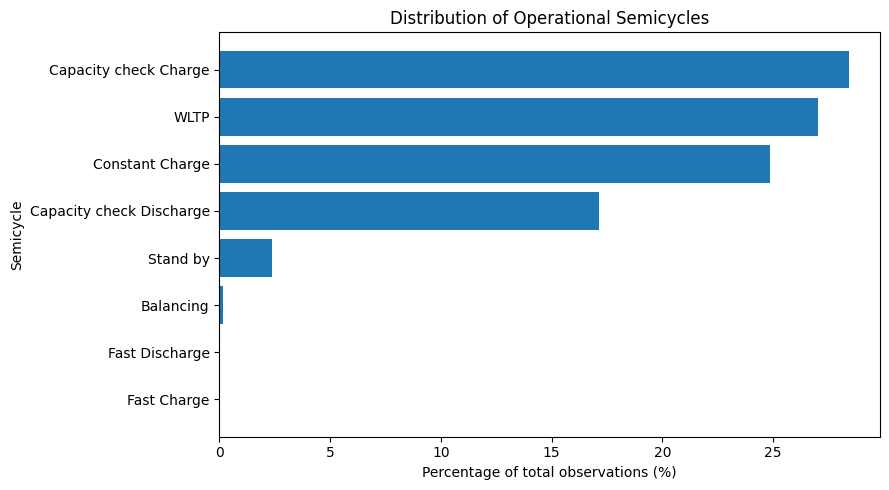

In [ ]:
import matplotlib.pyplot as plt

plot_data = semicycle_summary.sort_values(
    "percentage",
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.barh(
    plot_data["semicycle"],
    plot_data["percentage"]
)

plt.xlabel("Percentage of total observations (%)")
plt.ylabel("Semicycle")
plt.title("Distribution of Operational Semicycles")

plt.tight_layout()
plt.show()

# 3. EDA

Explore cell voltage, temperature and operating conditions before feature engineering.

## Voltage Behaviour

Examine voltage differences between cells during WLTP operation.

In [ ]:
cell_voltage_columns = [
    column for column in reference_columns
    if column.startswith("Voltage_Cell_")
]

wltp_file_names = quality_summary[
    quality_summary["semicycle_types"].apply(
        lambda semicycles: "WLTP" in semicycles
    )
]["file_name"].tolist()

# Use the middle WLTP cycle as a representative example
representative_file_name = wltp_file_names[
    len(wltp_file_names) // 2
]

representative_file = next(
    file_path
    for file_path in parquet_files
    if file_path.name == representative_file_name
)

wltp_df = pd.read_parquet(
    representative_file,
    columns=[
        "Timestamp",
        "Semicycle",
        "Current_Actual_Battery [A]",
        "SoC_Actual_Battery [percent]",
        *cell_voltage_columns
    ]
)

# Keep only WLTP observations
wltp_df = wltp_df[
    wltp_df["Semicycle"] == "WLTP"
].copy()

wltp_df["cell_voltage_min"] = (
    wltp_df[cell_voltage_columns].min(axis=1)
)

wltp_df["cell_voltage_mean"] = (
    wltp_df[cell_voltage_columns].mean(axis=1)
)

wltp_df["cell_voltage_max"] = (
    wltp_df[cell_voltage_columns].max(axis=1)
)

wltp_df["cell_voltage_spread"] = (
    wltp_df["cell_voltage_max"]
    - wltp_df["cell_voltage_min"]
)

print("Representative file:", representative_file.name)
print("WLTP observations:", f"{len(wltp_df):,}")

print("\nCell-voltage spread during WLTP [V]:")
display(
    wltp_df["cell_voltage_spread"]
    .describe()
    .round(5)
)

Representative file: Qtzl_Cycle_200_WLTP.parquet
WLTP observations: 24,445

Cell-voltage spread during WLTP [V]:


,cell_voltage_spread
count,24445.00000
mean,0.04652
std,0.05113
min,0.00600
25%,0.01700
50%,0.02900
75%,0.06200
max,1.28200


In [ ]:
wltp_df["min_voltage_cell"] = (
    wltp_df[cell_voltage_columns].idxmin(axis=1)
)

wltp_df["max_voltage_cell"] = (
    wltp_df[cell_voltage_columns].idxmax(axis=1)
)

high_spread_rows = (
    wltp_df[
        [
            "Timestamp",
            "Current_Actual_Battery [A]",
            "SoC_Actual_Battery [percent]",
            "cell_voltage_min",
            "cell_voltage_max",
            "cell_voltage_spread",
            "min_voltage_cell",
            "max_voltage_cell"
        ]
    ]
    .sort_values(
        "cell_voltage_spread",
        ascending=False
    )
    .head(15)
)

display(high_spread_rows)

,Timestamp,Current_Actual_Battery [A],SoC_Actual_Battery [percent],cell_voltage_min,cell_voltage_max,cell_voltage_spread,min_voltage_cell,max_voltage_cell
2494,2025-06-24 11:52:19.889794,-2.0,97.0,2.813,4.095,1.282,Voltage_Cell_P1S6 [V],Voltage_Cell_P2S2 [V]
6444,2025-06-24 12:13:23.864269,0.0,85.0,2.873,4.011,1.138,Voltage_Cell_P1S6 [V],Voltage_Cell_P3S2 [V]
6445,2025-06-24 12:13:24.184517,0.0,85.0,2.873,4.008,1.135,Voltage_Cell_P1S6 [V],Voltage_Cell_P1S3 [V]
21337,2025-06-24 13:32:49.522839,3.5,52.0,2.658,3.695,1.037,Voltage_Cell_P1S6 [V],Voltage_Cell_P3S1 [V]
14153,2025-06-24 12:54:30.684805,0.0,66.0,2.851,3.827,0.976,Voltage_Cell_P1S6 [V],Voltage_Cell_P3S1 [V]
14152,2025-06-24 12:54:30.374297,-8.3,66.0,2.851,3.815,0.964,Voltage_Cell_P1S6 [V],Voltage_Cell_P2S2 [V]
2989,2025-06-24 11:54:58.290523,-1.3,96.0,3.135,4.090,0.955,Voltage_Cell_P1S6 [V],Voltage_Cell_P2S2 [V]
2990,2025-06-24 11:54:58.610146,0.0,96.0,3.135,4.090,0.955,Voltage_Cell_P1S6 [V],Voltage_Cell_P2S2 [V]
1718,2025-06-24 11:48:11.581571,0.0,99.0,3.268,4.199,0.931,Voltage_Cell_P2S6 [V],Voltage_Cell_P1S7 [V]
1717,2025-06-24 11:48:11.262445,0.0,99.0,3.268,4.199,0.931,Voltage_Cell_P2S6 [V],Voltage_Cell_P1S7 [V]


In [ ]:
lowest_voltage_frequency = (
    wltp_df["min_voltage_cell"]
    .value_counts()
    .rename_axis("cell")
    .reset_index(name="lowest_voltage_count")
)

lowest_voltage_frequency["percentage"] = (
    lowest_voltage_frequency["lowest_voltage_count"]
    / len(wltp_df)
    * 100
)

display(
    lowest_voltage_frequency
    .head(15)
    .round({"percentage": 2})
)

,cell,lowest_voltage_count,percentage
0,Voltage_Cell_P1S6 [V],20204,82.65
1,Voltage_Cell_P1S12 [V],1727,7.06
2,Voltage_Cell_P2S12 [V],1359,5.56
3,Voltage_Cell_P3S6 [V],443,1.81
4,Voltage_Cell_P1S1 [V],281,1.15
5,Voltage_Cell_P2S6 [V],170,0.70
6,Voltage_Cell_P3S12 [V],113,0.46
7,Voltage_Cell_P1S5 [V],46,0.19
8,Voltage_Cell_P3S1 [V],22,0.09
9,Voltage_Cell_P2S4 [V],19,0.08


In [ ]:
# Find the dominant lowest-voltage cell in each WLTP cycle
wltp_lowest_cell_records = []

for file_path in parquet_files:

    if file_path.name not in wltp_file_names:
        continue

    df = pd.read_parquet(
        file_path,
        columns=["Semicycle", *cell_voltage_columns]
    )

    wltp_data = df[df["Semicycle"] == "WLTP"]

    if len(wltp_data) == 0:
        continue

    lowest_cell = (
        wltp_data[cell_voltage_columns]
        .idxmin(axis=1)
    )

    counts = lowest_cell.value_counts()

    most_frequent_cell = counts.index[0]
    most_frequent_count = counts.iloc[0]

    cycle_number = int(
        quality_summary.loc[
            quality_summary["file_name"] == file_path.name,
            "expected_cycle"
        ].iloc[0]
    )

    wltp_lowest_cell_records.append({
        "cycle": cycle_number,
        "lowest_voltage_cell": most_frequent_cell,
        "count": int(most_frequent_count),
        "percentage": most_frequent_count / len(wltp_data) * 100
    })

wltp_lowest_cell_summary = pd.DataFrame(
    wltp_lowest_cell_records
).sort_values("cycle").reset_index(drop=True)

display(wltp_lowest_cell_summary.head(20).round({"percentage": 2}))

,cycle,lowest_voltage_cell,count,percentage
0,2,Voltage_Cell_P1S12 [V],4030,42.74
1,3,Voltage_Cell_P1S4 [V],5068,14.76
2,4,Voltage_Cell_P2S3 [V],5829,18.76
3,5,Voltage_Cell_P3S12 [V],8301,29.09
4,6,Voltage_Cell_P1S6 [V],5531,19.71
5,7,Voltage_Cell_P2S9 [V],5160,17.23
6,8,Voltage_Cell_P1S11 [V],5098,17.74
7,9,Voltage_Cell_P2S9 [V],4272,13.69
8,10,Voltage_Cell_P3S12 [V],5735,19.23
9,11,Voltage_Cell_P2S9 [V],5659,17.51


In [ ]:
dominant_cell_summary = (
    wltp_lowest_cell_summary["lowest_voltage_cell"]
    .value_counts()
    .rename_axis("cell")
    .reset_index(name="dominant_cycle_count")
)

dominant_cell_summary["percentage_of_wltp_cycles"] = (
    dominant_cell_summary["dominant_cycle_count"]
    / len(wltp_lowest_cell_summary)
    * 100
)

display(
    dominant_cell_summary
    .head(15)
    .round({"percentage_of_wltp_cycles": 2})
)

,cell,dominant_cycle_count,percentage_of_wltp_cycles
0,Voltage_Cell_P1S6 [V],213,66.56
1,Voltage_Cell_P2S9 [V],58,18.12
2,Voltage_Cell_P2S8 [V],19,5.94
3,Voltage_Cell_P2S6 [V],8,2.50
4,Voltage_Cell_P3S12 [V],6,1.88
5,Voltage_Cell_P1S12 [V],3,0.94
6,Voltage_Cell_P3S6 [V],3,0.94
7,Voltage_Cell_P1S4 [V],2,0.62
8,Voltage_Cell_P1S11 [V],2,0.62
9,Voltage_Cell_P2S3 [V],1,0.31


## Temperature Behaviour

Check temperature patterns and identify unreliable sensor readings.

In [ ]:
cell_ids = [
    f"P{branch}S{series}"
    for branch in range(1, 4)
    for series in range(1, 13)
]

wltp_temperature_df = pd.read_parquet(
    representative_file,
    columns=["Semicycle", *cell_temperature_columns]
)

wltp_temperature_df = wltp_temperature_df[
    wltp_temperature_df["Semicycle"] == "WLTP"
].copy()

# Average the top and bottom sensors for each cell.
cell_average_temperature_columns = []

for cell in cell_ids:

    new_column = f"Temperature_{cell}"

    wltp_temperature_df[new_column] = (
        wltp_temperature_df[
            [
                f"Temperature_Cell_Top_{cell} [degC]",
                f"Temperature_Cell_Bottom_{cell} [degC]"
            ]
        ].mean(axis=1)
    )

    cell_average_temperature_columns.append(new_column)

wltp_temperature_df["cell_temperature_min"] = (
    wltp_temperature_df[cell_average_temperature_columns].min(axis=1)
)

wltp_temperature_df["cell_temperature_mean"] = (
    wltp_temperature_df[cell_average_temperature_columns].mean(axis=1)
)

wltp_temperature_df["cell_temperature_max"] = (
    wltp_temperature_df[cell_average_temperature_columns].max(axis=1)
)

wltp_temperature_df["cell_temperature_spread"] = (
    wltp_temperature_df["cell_temperature_max"]
    - wltp_temperature_df["cell_temperature_min"]
)

print("WLTP observations:", f"{len(wltp_temperature_df):,}")

print("\nCell-temperature spread during WLTP [degC]:")
display(
    wltp_temperature_df["cell_temperature_spread"]
    .describe()
    .round(3)
)

WLTP observations: 24,445

Cell-temperature spread during WLTP [degC]:


,cell_temperature_spread
count,24445.000
mean,326.872
std,290.844
min,31.770
25%,33.105
50%,310.300
75%,635.410
max,639.050


In [ ]:
temperature_range_check = pd.DataFrame({
    "min_temperature": wltp_temperature_df[cell_temperature_columns].min(),
    "max_temperature": wltp_temperature_df[cell_temperature_columns].max()
})

print("Lowest recorded temperatures:")
display(
    temperature_range_check
    .sort_values("min_temperature")
    .head(10)
)

print("\nHighest recorded temperatures:")
display(
    temperature_range_check
    .sort_values("max_temperature", ascending=False)
    .head(10)
)

Lowest recorded temperatures:


,min_temperature,max_temperature
Temperature_Cell_Top_P3S11 [degC],0.050000,655.309998
Temperature_Cell_Bottom_P3S11 [degC],0.050000,655.309998
Temperature_Cell_Bottom_P1S5 [degC],11.190000,20.379999
Temperature_Cell_Top_P1S5 [degC],11.370000,20.820000
Temperature_Cell_Bottom_P1S2 [degC],24.270000,38.500000
Temperature_Cell_Top_P1S10 [degC],24.570000,36.480000
Temperature_Cell_Bottom_P3S10 [degC],24.860001,36.000000
Temperature_Cell_Bottom_P2S8 [degC],25.040001,36.009998
Temperature_Cell_Top_P1S11 [degC],25.219999,34.220001
Temperature_Cell_Top_P2S4 [degC],25.230000,38.790001



Highest recorded temperatures:


,min_temperature,max_temperature
Temperature_Cell_Bottom_P3S11 [degC],0.050000,655.309998
Temperature_Cell_Top_P3S11 [degC],0.050000,655.309998
Temperature_Cell_Bottom_P2S2 [degC],27.139999,39.779999
Temperature_Cell_Top_P2S4 [degC],25.230000,38.790001
Temperature_Cell_Bottom_P1S2 [degC],24.270000,38.500000
Temperature_Cell_Bottom_P3S8 [degC],25.500000,38.380001
Temperature_Cell_Bottom_P2S3 [degC],26.900000,37.810001
Temperature_Cell_Top_P1S4 [degC],27.120001,37.240002
Temperature_Cell_Top_P3S3 [degC],26.469999,37.220001
Temperature_Cell_Bottom_P1S3 [degC],27.870001,37.160000


In [ ]:
# Check temperature ranges across all cycles.
global_temperature_min = {
    column: float("inf")
    for column in cell_temperature_columns
}

global_temperature_max = {
    column: float("-inf")
    for column in cell_temperature_columns
}

for file_path in parquet_files:

    df = pd.read_parquet(
        file_path,
        columns=cell_temperature_columns
    )

    file_min = df.min()
    file_max = df.max()

    for column in cell_temperature_columns:
        global_temperature_min[column] = min(
            global_temperature_min[column],
            file_min[column]
        )

        global_temperature_max[column] = max(
            global_temperature_max[column],
            file_max[column]
        )

temperature_sensor_summary = pd.DataFrame({
    "global_min": global_temperature_min,
    "global_max": global_temperature_max
})

print("Highest temperature ranges:")
display(
    temperature_sensor_summary
    .sort_values("global_max", ascending=False)
    .head(15)
    .round(2)
)

print("\nLowest temperature ranges:")
display(
    temperature_sensor_summary
    .sort_values("global_min")
    .head(15)
    .round(2)
)

Highest temperature ranges:


,global_min,global_max
Temperature_Cell_Bottom_P3S11 [degC],0.050000,655.309998
Temperature_Cell_Top_P3S11 [degC],0.050000,655.309998
Temperature_Cell_Bottom_P1S5 [degC],0.030000,655.280029
Temperature_Cell_Top_P1S5 [degC],0.030000,655.280029
Temperature_Cell_Bottom_P2S6 [degC],22.650000,382.209991
Temperature_Cell_Top_P2S6 [degC],21.420000,382.209991
Temperature_Cell_Bottom_P2S5 [degC],22.129999,382.209991
Temperature_Cell_Top_P2S5 [degC],22.299999,382.209991
Temperature_Cell_Bottom_P2S10 [degC],22.830000,153.759995
Temperature_Cell_Bottom_P3S2 [degC],22.260000,43.570000



Lowest temperature ranges:


,global_min,global_max
Temperature_Cell_Bottom_P1S5 [degC],0.030000,655.280029
Temperature_Cell_Top_P1S5 [degC],0.030000,655.280029
Temperature_Cell_Top_P3S11 [degC],0.050000,655.309998
Temperature_Cell_Bottom_P3S11 [degC],0.050000,655.309998
Temperature_Cell_Bottom_P1S2 [degC],18.730000,42.500000
Temperature_Cell_Bottom_P1S4 [degC],18.740000,42.509998
Temperature_Cell_Top_P2S11 [degC],18.959999,39.840000
Temperature_Cell_Bottom_P1S3 [degC],19.530001,42.619999
Temperature_Cell_Top_P1S6 [degC],19.590000,42.029999
Temperature_Cell_Bottom_P1S6 [degC],20.030001,41.369999


In [ ]:
# Dataset-specific screening range: 5–80°C.
suspicious_temperature_sensors = temperature_sensor_summary[
    (temperature_sensor_summary["global_min"] < 5)
    | (temperature_sensor_summary["global_max"] > 80)
].copy()

display(
    suspicious_temperature_sensors
    .sort_values("global_max", ascending=False)
    .round(2)
)

print(
    "Suspicious temperature sensors:",
    len(suspicious_temperature_sensors)
)

,global_min,global_max
Temperature_Cell_Top_P3S11 [degC],0.050000,655.309998
Temperature_Cell_Bottom_P3S11 [degC],0.050000,655.309998
Temperature_Cell_Top_P1S5 [degC],0.030000,655.280029
Temperature_Cell_Bottom_P1S5 [degC],0.030000,655.280029
Temperature_Cell_Top_P2S5 [degC],22.299999,382.209991
Temperature_Cell_Top_P2S6 [degC],21.420000,382.209991
Temperature_Cell_Bottom_P2S5 [degC],22.129999,382.209991
Temperature_Cell_Bottom_P2S6 [degC],22.650000,382.209991
Temperature_Cell_Bottom_P2S10 [degC],22.830000,153.759995


Suspicious temperature sensors: 9


In [ ]:
# Count invalid readings for each suspicious sensor.
temperature_issue_records = []

for file_path in parquet_files:

    df = pd.read_parquet(
        file_path,
        columns=suspicious_temperature_sensors.index.tolist()
    )

    for column in suspicious_temperature_sensors.index:

        invalid_count = (
            (df[column] < 5)
            | (df[column] > 80)
        ).sum()

        temperature_issue_records.append({
            "sensor": column,
            "total_rows": len(df),
            "invalid_rows": int(invalid_count)
        })

temperature_issue_summary = (
    pd.DataFrame(temperature_issue_records)
    .groupby("sensor", as_index=False)
    .sum()
)

temperature_issue_summary["invalid_percentage"] = (
    temperature_issue_summary["invalid_rows"]
    / temperature_issue_summary["total_rows"]
    * 100
)

display(
    temperature_issue_summary
    .sort_values("invalid_percentage", ascending=False)
    .round({"invalid_percentage": 2})
)

,sensor,total_rows,invalid_rows,invalid_percentage
8,Temperature_Cell_Top_P3S11 [degC],30187165,30122426,99.79
4,Temperature_Cell_Bottom_P3S11 [degC],30187165,30117883,99.77
5,Temperature_Cell_Top_P1S5 [degC],30187165,8630774,28.59
0,Temperature_Cell_Bottom_P1S5 [degC],30187165,8190548,27.13
2,Temperature_Cell_Bottom_P2S5 [degC],30187165,433,0.00
6,Temperature_Cell_Top_P2S5 [degC],30187165,433,0.00
3,Temperature_Cell_Bottom_P2S6 [degC],30187165,433,0.00
7,Temperature_Cell_Top_P2S6 [degC],30187165,433,0.00
1,Temperature_Cell_Bottom_P2S10 [degC],30187165,66,0.00


### Temperature Cleaning

For this dataset, values outside 5–80°C are treated as implausible sensor readings. P1S5 and P3S11 are excluded from the cleaned multi-cell temperature comparison because of persistent sensor issues.

In [ ]:
import numpy as np

clean_temperature_df = wltp_temperature_df.copy()

# Mask values outside 5–80°C
clean_temperature_df[cell_temperature_columns] = (
    clean_temperature_df[cell_temperature_columns]
    .mask(
        (clean_temperature_df[cell_temperature_columns] < 5)
        | (clean_temperature_df[cell_temperature_columns] > 80)
    )
)

print("Cleaned temperature data created.")

Cleaned temperature data created.


In [ ]:
# Exclude cells with persistent temperature sensor issuess
reliable_temperature_cells = [
    cell for cell in cell_ids
    if cell not in ["P1S5", "P3S11"]
]

clean_temperature_columns = {
    f"Clean_Temperature_{cell}": (
        clean_temperature_df[
            [
                f"Temperature_Cell_Top_{cell} [degC]",
                f"Temperature_Cell_Bottom_{cell} [degC]"
            ]
        ].mean(axis=1)
    )
    for cell in reliable_temperature_cells
}

clean_temperature_df = pd.concat(
    [
        clean_temperature_df,
        pd.DataFrame(
            clean_temperature_columns,
            index=clean_temperature_df.index
        )
    ],
    axis=1
)

reliable_temperature_columns = list(
    clean_temperature_columns.keys()
)

clean_temperature_df["temperature_min"] = (
    clean_temperature_df[reliable_temperature_columns]
    .min(axis=1)
)

clean_temperature_df["temperature_mean"] = (
    clean_temperature_df[reliable_temperature_columns]
    .mean(axis=1)
)

clean_temperature_df["temperature_max"] = (
    clean_temperature_df[reliable_temperature_columns]
    .max(axis=1)
)

clean_temperature_df["temperature_spread"] = (
    clean_temperature_df["temperature_max"]
    - clean_temperature_df["temperature_min"]
)

print(
    "Cleaned cell-temperature spread during WLTP [degC]:"
)

display(
    clean_temperature_df["temperature_spread"]
    .describe()
    .round(3)
)

Cleaned cell-temperature spread during WLTP [degC]:


,temperature_spread
count,24445.000
mean,3.464
std,0.468
min,2.500
25%,3.175
50%,3.470
75%,3.720
max,6.270


### Sensor Investigation

P1S5 is checked across WLTP cycles to confirm whether its unusual temperature behaviour is persistent.

In [ ]:
p1s5_relative_records = []

p1s5_comparison_cells = [
    cell for cell in cell_ids
    if cell != "P3S11"
]

for file_name in wltp_file_names:

    file_path = DATA_DIR / file_name

    df = pd.read_parquet(
        file_path,
        columns=["Semicycle", *cell_temperature_columns]
    )

    df = df[df["Semicycle"] == "WLTP"].copy()

    if len(df) == 0:
        continue

    #   Mask implausible temperature values.
    temperature_data = df[cell_temperature_columns].mask(
        (df[cell_temperature_columns] < 5)
        | (df[cell_temperature_columns] > 80)
    )

    cell_temperatures = {}

    for cell in p1s5_comparison_cells:

        cell_temperatures[cell] = temperature_data[
            [
                f"Temperature_Cell_Top_{cell} [degC]",
                f"Temperature_Cell_Bottom_{cell} [degC]"
            ]
        ].mean(axis=1)

    cell_temperature_df = pd.DataFrame(cell_temperatures)

    p1s5_median = cell_temperature_df["P1S5"].median()

    other_cells_median = (
        cell_temperature_df
        .drop(columns="P1S5")
        .median(axis=1)
        .median()
    )

    p1s5_relative_records.append({
        "file": file_name,
        "P1S5_median": p1s5_median,
        "other_cells_median": other_cells_median,
        "difference": p1s5_median - other_cells_median
    })

p1s5_relative_summary = pd.DataFrame(
    p1s5_relative_records
)

display(
    p1s5_relative_summary["difference"]
    .describe()
    .round(2)
)

print("\nCycles with the largest negative P1S5 temperature difference:")

display(
    p1s5_relative_summary
    .sort_values("difference")
    .head(10)
    .round(2)
)

,difference
count,299.00
mean,-8.02
std,9.14
min,-27.51
25%,-17.81
50%,-2.52
75%,-0.57
max,2.31



Cycles with the largest negative P1S5 temperature difference:


,file,P1S5_median,other_cells_median,difference
271,Qtzl_Cycle_348_WLTP.parquet,5.59,33.10,-27.51
266,Qtzl_Cycle_339_WLTP.parquet,6.40,33.17,-26.76
258,Qtzl_Cycle_329_WLTP.parquet,5.93,32.40,-26.47
143,Qtzl_Cycle_179_WLTP.parquet,5.88,31.29,-25.41
205,Qtzl_Cycle_262_WLTP.parquet,6.07,30.77,-24.70
246,Qtzl_Cycle_315_WLTP.parquet,6.07,30.15,-24.08
272,Qtzl_Cycle_349_WLTP.parquet,5.49,29.28,-23.79
180,Qtzl_Cycle_226_WLTP.parquet,6.69,30.42,-23.73
125,Qtzl_Cycle_153_WLTP.parquet,5.40,28.92,-23.52
293,Qtzl_Cycle_376_WLTP.parquet,5.64,28.92,-23.28


In [ ]:
hottest_cell_frequency = (
    clean_temperature_df[reliable_temperature_columns]
    .idxmax(axis=1)
    .value_counts()
    .rename_axis("cell")
    .reset_index(name="hottest_count")
)

hottest_cell_frequency["percentage"] = (
    hottest_cell_frequency["hottest_count"]
    / len(clean_temperature_df)
    * 100
)

display(
    hottest_cell_frequency
    .head(10)
    .round({"percentage": 2})
)

,cell,hottest_count,percentage
0,Clean_Temperature_P2S4,8466,34.63
1,Clean_Temperature_P1S4,7965,32.58
2,Clean_Temperature_P1S3,2727,11.16
3,Clean_Temperature_P2S6,1327,5.43
4,Clean_Temperature_P2S5,761,3.11
5,Clean_Temperature_P1S6,705,2.88
6,Clean_Temperature_P3S3,694,2.84
7,Clean_Temperature_P3S9,265,1.08
8,Clean_Temperature_P2S3,234,0.96
9,Clean_Temperature_P3S4,229,0.94


## Operating Conditions

Check whether current or SoC is related to cell-voltage spread.

In [ ]:
operating_context_summary = wltp_df[
    [
        "Current_Actual_Battery [A]",
        "SoC_Actual_Battery [percent]",
        "cell_voltage_spread"
    ]
].describe()

display(
    operating_context_summary.round(3)
)

,Current_Actual_Battery [A],SoC_Actual_Battery [percent],cell_voltage_spread
count,24445.000,24445.000,24445.000
mean,-2.256,72.015,0.047
std,4.208,17.242,0.051
min,-19.000,43.000,0.006
25%,-4.500,57.000,0.017
50%,-0.700,68.000,0.029
75%,0.000,86.000,0.062
max,4.700,99.000,1.282


In [ ]:
context_df = wltp_df[
    [
        "Current_Actual_Battery [A]",
        "SoC_Actual_Battery [percent]",
        "cell_voltage_spread"
    ]
].copy()

# Use absolute current so charge/discharge direction does not cancel.
context_df["absolute_current"] = (
    context_df["Current_Actual_Battery [A]"].abs()
)

context_correlations = (
    context_df[
        [
            "absolute_current",
            "SoC_Actual_Battery [percent]",
            "cell_voltage_spread"
        ]
    ]
    .corr(method="spearman")["cell_voltage_spread"]
    .drop("cell_voltage_spread")
)

display(
    context_correlations
    .rename("correlation_with_voltage_spread")
    .round(3)
)

,correlation_with_voltage_spread
absolute_current,0.828
SoC_Actual_Battery [percent],0.153


# 4. Feature Engineering

Convert raw WLTP measurements into one feature row for each cell and cycle.

In [ ]:
feature_records = []

for file_name in wltp_file_names:

    file_path = DATA_DIR / file_name

    df = pd.read_parquet(
        file_path,
        columns=[
            "Semicycle",
            "Current_Actual_Battery [A]",
            *cell_voltage_columns
        ]
    )

    wltp = df[df["Semicycle"] == "WLTP"].copy()

    if len(wltp) == 0:
        continue

    cycle_number = int(file_name.split("_")[2])

    # Use pack-average cell voltage as the reference
    pack_voltage_mean = (
        wltp[cell_voltage_columns]
        .mean(axis=1)
    )

    lowest_voltage_cell = (
        wltp[cell_voltage_columns]
        .idxmin(axis=1)
    )

    # High load = top 25% of absolute current
    absolute_current = (
        wltp["Current_Actual_Battery [A]"].abs()
    )

    high_load_threshold = (
        absolute_current.quantile(0.75)
    )

    high_load_mask = (
        absolute_current >= high_load_threshold
    )

    for cell in cell_ids:

        voltage_column = f"Voltage_Cell_{cell} [V]"

        feature_records.append({
            "cycle": cycle_number,
            "cell": cell,

            "voltage_mean":
                wltp[voltage_column].mean(),

            "voltage_min":
                wltp[voltage_column].min(),

            "voltage_deviation":
                (
                    wltp[voltage_column]
                    - pack_voltage_mean
                ).abs().mean(),

            "lowest_voltage_frequency":
                (
                    lowest_voltage_cell
                    == voltage_column
                ).mean() * 100,

            "high_load_voltage_deviation":
                (
                    wltp.loc[high_load_mask, voltage_column]
                    - pack_voltage_mean[high_load_mask]
                ).abs().mean()
        })

base_feature_df = (
    pd.DataFrame(feature_records)
    .sort_values(["cell", "cycle"])
    .reset_index(drop=True)
)

print("Feature table shape:", base_feature_df.shape)

display(
    base_feature_df.head(10).round(4)
)

Feature table shape: (11520, 7)


,cycle,cell,voltage_mean,voltage_min,voltage_deviation,lowest_voltage_frequency,high_load_voltage_deviation
0,2,P1S1,4.1673,4.006,0.0152,0.5833,0.0308
1,3,P1S1,3.9796,3.504,0.0550,0.0000,0.0848
2,4,P1S1,4.0199,3.565,0.0567,0.0000,0.0878
3,5,P1S1,4.0091,3.416,0.0570,0.0000,0.0697
4,6,P1S1,3.9418,3.499,0.0333,0.0000,0.0514
5,7,P1S1,3.9558,3.504,0.0361,0.0000,0.0518
6,8,P1S1,3.8553,3.305,0.0389,0.0313,0.0572
7,9,P1S1,3.9013,3.351,0.0447,0.5543,0.0675
8,10,P1S1,3.9071,3.241,0.0423,0.0000,0.0761
9,11,P1S1,3.8994,3.397,0.0343,0.0000,0.0514


### Temporal Feature

Add the change from the previous WLTP cycle to capture behaviour over time.

In [ ]:
# Add previous-WLTP-cycle change in voltage deviation,
base_feature_df["voltage_deviation_change"] = (
    base_feature_df
    .groupby("cell")["voltage_deviation"]
    .diff()
)

print(
    "Missing history values:",
    base_feature_df["voltage_deviation_change"].isna().sum()
)

display(
    base_feature_df[
        [
            "cycle",
            "cell",
            "voltage_deviation",
            "voltage_deviation_change"
        ]
    ]
    .head(10)
    .round(4)
)

Missing history values: 36


,cycle,cell,voltage_deviation,voltage_deviation_change
0,2,P1S1,0.0152,NaN
1,3,P1S1,0.0550,0.0398
2,4,P1S1,0.0567,0.0017
3,5,P1S1,0.0570,0.0004
4,6,P1S1,0.0333,-0.0237
5,7,P1S1,0.0361,0.0028
6,8,P1S1,0.0389,0.0029
7,9,P1S1,0.0447,0.0057
8,10,P1S1,0.0423,-0.0024
9,11,P1S1,0.0343,-0.0080


# 5. Modelling Preparation

Prepare the final feature set for unsupervised anomaly detection.

In [ ]:
base_feature_columns = [
    "voltage_mean",
    "voltage_min",
    "voltage_deviation",
    "lowest_voltage_frequency",
    "high_load_voltage_deviation",
    "voltage_deviation_change"
]

# Drop rows without previous-cycle information.
base_model_df = (
    base_feature_df
    .dropna(subset=base_feature_columns)
    .reset_index(drop=True)
)

print("Base model dataset shape:", base_model_df.shape)

display(
    base_model_df.head(10).round(4)
)

Base model dataset shape: (11484, 8)


,cycle,cell,voltage_mean,voltage_min,voltage_deviation,lowest_voltage_frequency,high_load_voltage_deviation,voltage_deviation_change
0,3,P1S1,3.9796,3.504,0.0550,0.0000,0.0848,0.0398
1,4,P1S1,4.0199,3.565,0.0567,0.0000,0.0878,0.0017
2,5,P1S1,4.0091,3.416,0.0570,0.0000,0.0697,0.0004
3,6,P1S1,3.9418,3.499,0.0333,0.0000,0.0514,-0.0237
4,7,P1S1,3.9558,3.504,0.0361,0.0000,0.0518,0.0028
5,8,P1S1,3.8553,3.305,0.0389,0.0313,0.0572,0.0029
6,9,P1S1,3.9013,3.351,0.0447,0.5543,0.0675,0.0057
7,10,P1S1,3.9071,3.241,0.0423,0.0000,0.0761,-0.0024
8,11,P1S1,3.8994,3.397,0.0343,0.0000,0.0514,-0.0080
9,12,P1S1,3.8770,3.413,0.1009,0.0000,0.1154,0.0666


### Chronological Split

Use earlier WLTP cycles for training and later unseen cycles for testing.

In [ ]:
# Earlier 70% of cycles for training, later 30% for testing .
unique_cycles = sorted(base_model_df["cycle"].unique())

split_index = int(len(unique_cycles) * 0.70)

train_cycles = unique_cycles[:split_index]
test_cycles = unique_cycles[split_index:]

train_df = base_model_df[
    base_model_df["cycle"].isin(train_cycles)
].copy()

test_df = base_model_df[
    base_model_df["cycle"].isin(test_cycles)
].copy()

print("Training cycles:", len(train_cycles))
print("Testing cycles:", len(test_cycles))

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

print("Last training cycle:", max(train_cycles))
print("First testing cycle:", min(test_cycles))

Training cycles: 223
Testing cycles: 96
Training shape: (8028, 8)
Testing shape: (3456, 8)
Last training cycle: 286
First testing cycle: 287


In [ ]:
from sklearn.preprocessing import StandardScaler

X_train = train_df[base_feature_columns].copy()
X_test = test_df[base_feature_columns].copy()

# Fit only on training data to avoid data leakage.
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=base_feature_columns,
    index=train_df.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=base_feature_columns,
    index=test_df.index
)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

display(
    X_train_scaled.head().round(3)
)

Scaled training shape: (8028, 6)
Scaled testing shape: (3456, 6)


,voltage_mean,voltage_min,voltage_deviation,lowest_voltage_frequency,high_load_voltage_deviation,voltage_deviation_change
0,0.418,0.454,1.580,-0.247,1.351,2.187
1,0.695,0.626,1.658,-0.247,1.434,0.093
2,0.621,0.207,1.676,-0.247,0.929,0.022
3,0.158,0.440,0.563,-0.247,0.421,-1.303
4,0.255,0.454,0.693,-0.247,0.433,0.154


# 6. Unsupervised Anomaly Detection

Three models are compared: Isolation Forest, One-Class SVM and Autoencoder.

## Isolation Forest

In [ ]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42
)

isolation_forest.fit(X_train_scaled)

# Reverse the score so higher values mean more unusual behaviour.
isolation_forest_scores = -isolation_forest.score_samples(
    X_test_scaled
)

isolation_forest_results = test_df[
    ["cycle", "cell"]
].copy()

isolation_forest_results["anomaly_score"] = (
    isolation_forest_scores
)

display(
    isolation_forest_results
    .sort_values("anomaly_score", ascending=False)
    .head(15)
    .round(4)
)

,cycle,cell,anomaly_score
2861,397,P1S6,0.7503
2856,392,P1S6,0.7498
2866,404,P1S6,0.7480
2858,394,P1S6,0.7472
2857,393,P1S6,0.7448
2862,398,P1S6,0.7448
2860,396,P1S6,0.7427
2859,395,P1S6,0.7415
2870,410,P1S6,0.7412
2863,399,P1S6,0.7404


In [ ]:
isolation_forest_cell_summary = (
    isolation_forest_results
    .groupby("cell")["anomaly_score"]
    .agg(
        mean_anomaly_score="mean",
        max_anomaly_score="max"
    )
    .reset_index()
    .sort_values("mean_anomaly_score", ascending=False)
)

display(
    isolation_forest_cell_summary
    .head(15)
    .round(4)
)

,cell,mean_anomaly_score,max_anomaly_score
8,P1S6,0.7005,0.7503
20,P2S6,0.4944,0.7167
3,P1S12,0.4732,0.5602
24,P3S1,0.4711,0.6054
15,P2S12,0.4233,0.5281
30,P3S4,0.4223,0.5195
7,P1S5,0.4171,0.5356
10,P1S8,0.4077,0.5136
11,P1S9,0.4076,0.5134
6,P1S4,0.4074,0.5433


## One-Class SVM

In [ ]:
from sklearn.svm import OneClassSVM

one_class_svm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.05
)

one_class_svm.fit(X_train_scaled)

# Reverse the score so higher values mean more unusual behaviour.
ocsvm_scores = -one_class_svm.decision_function(
    X_test_scaled
)

ocsvm_results = test_df[
    ["cycle", "cell"]
].copy()

ocsvm_results["anomaly_score"] = ocsvm_scores

display(
    ocsvm_results
    .sort_values("anomaly_score", ascending=False)
    .head(15)
    .round(4)
)

,cycle,cell,anomaly_score
2861,397,P1S6,28.7387
2781,297,P1S6,27.3106
2856,392,P1S6,25.5804
2823,349,P1S6,22.1636
2862,398,P1S6,21.7767
2857,393,P1S6,21.4174
6651,349,P2S6,20.6879
6610,298,P2S6,19.1289
2863,399,P1S6,18.7688
2793,311,P1S6,18.6910


In [ ]:
ocsvm_cell_summary = (
    ocsvm_results
    .groupby("cell")["anomaly_score"]
    .agg(
        mean_anomaly_score="mean",
        max_anomaly_score="max"
    )
    .reset_index()
    .sort_values("mean_anomaly_score", ascending=False)
)

display(
    ocsvm_cell_summary
    .head(15)
    .round(4)
)

,cell,mean_anomaly_score,max_anomaly_score
8,P1S6,6.4000,28.7387
13,P2S10,-2.3382,1.3167
21,P2S7,-2.3610,0.3544
17,P2S3,-2.4086,1.2898
31,P3S5,-2.4106,1.0973
24,P3S1,-2.5179,9.1621
20,P2S6,-2.5255,20.6879
22,P2S8,-2.5428,1.0420
26,P3S11,-2.6833,0.1918
1,P1S10,-2.7775,1.5312


### Anomaly Persistence

Count how often each cell remains anomalous across the test cycles.

In [ ]:
# Positive scores are treated as anomalous .
ocsvm_results["is_anomalous"] = (
    ocsvm_results["anomaly_score"] > 0
)

ocsvm_persistence_summary = (
    ocsvm_results
    .groupby("cell")["is_anomalous"]
    .agg(
        anomalous_cycles="sum",
        total_cycles="count"
    )
    .reset_index()
)

ocsvm_persistence_summary["anomalous_percentage"] = (
    ocsvm_persistence_summary["anomalous_cycles"]
    / ocsvm_persistence_summary["total_cycles"]
    * 100
)

display(
    ocsvm_persistence_summary
    .sort_values("anomalous_percentage", ascending=False)
    .head(15)
    .round({"anomalous_percentage": 2})
)

,cell,anomalous_cycles,total_cycles,anomalous_percentage
8,P1S6,73,96,76.04
24,P3S1,15,96,15.62
20,P2S6,13,96,13.54
30,P3S4,4,96,4.17
17,P2S3,3,96,3.12
3,P1S12,3,96,3.12
1,P1S10,2,96,2.08
18,P2S4,2,96,2.08
21,P2S7,2,96,2.08
13,P2S10,2,96,2.08


## Autoencoder

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

# Reproducible TensorFlow setup
tf.keras.backend.clear_session()

tf.keras.utils.set_random_seed(42)

tf.config.experimental.enable_op_determinism()

# Autoencoder architecture
autoencoder = Sequential([
    Input(shape=(len(base_feature_columns),)),
    Dense(4, activation="relu"),
    Dense(2, activation="relu"),
    Dense(4, activation="relu"),
    Dense(len(base_feature_columns), activation="linear")
])

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

# Train the model to reconstruct the training features.
history = autoencoder.fit(
    X_train_scaled,
    X_train_scaled,
    epochs=50,
    batch_size=128,
    shuffle=True,
    verbose=0
)

train_reconstructed = autoencoder.predict(
    X_train_scaled,
    verbose=0
)

test_reconstructed = autoencoder.predict(
    X_test_scaled,
    verbose=0
)

# Reconstruction error is used as the anomaly score.
train_reconstruction_error = np.mean(
    (X_train_scaled.values - train_reconstructed) ** 2,
    axis=1
)

test_reconstruction_error = np.mean(
    (X_test_scaled.values - test_reconstructed) ** 2,
    axis=1
)

# Threshold = 95th percentile of training reconstruction error.
autoencoder_threshold = np.percentile(
    train_reconstruction_error,
    95
)

autoencoder_results = test_df[
    ["cycle", "cell"]
].copy()

autoencoder_results["anomaly_score"] = (
    test_reconstruction_error
)

autoencoder_results["is_anomalous"] = (
    autoencoder_results["anomaly_score"]
    > autoencoder_threshold
)

print(
    "Autoencoder anomaly threshold:",
    round(autoencoder_threshold, 4)
)

display(
    autoencoder_results
    .sort_values("anomaly_score", ascending=False)
    .head(15)
    .round(4)
)

Autoencoder anomaly threshold: 2.5426


,cycle,cell,anomaly_score,is_anomalous
2861,397,P1S6,14.5766,True
2855,389,P1S6,13.9074,True
2866,404,P1S6,13.6828,True
2860,396,P1S6,13.5868,True
2856,392,P1S6,13.4893,True
2858,394,P1S6,13.3962,True
2862,398,P1S6,13.1443,True
2857,393,P1S6,13.0586,True
2859,395,P1S6,12.9930,True
2863,399,P1S6,12.8576,True


In [ ]:
autoencoder_cell_summary = (
    autoencoder_results
    .groupby("cell")
    .agg(
        mean_anomaly_score=("anomaly_score", "mean"),
        max_anomaly_score=("anomaly_score", "max"),
        anomalous_cycles=("is_anomalous", "sum"),
        total_cycles=("is_anomalous", "count")
    )
    .reset_index()
)

autoencoder_cell_summary["anomalous_percentage"] = (
    autoencoder_cell_summary["anomalous_cycles"]
    / autoencoder_cell_summary["total_cycles"]
    * 100
)

display(
    autoencoder_cell_summary
    .sort_values("anomalous_percentage", ascending=False)
    .head(15)
    .round({
        "mean_anomaly_score": 4,
        "max_anomaly_score": 4,
        "anomalous_percentage": 2
    })
)

,cell,mean_anomaly_score,max_anomaly_score,anomalous_cycles,total_cycles,anomalous_percentage
8,P1S6,9.6361,14.5766,91,96,94.79
20,P2S6,0.9011,11.4705,6,96,6.25
0,P1S1,0.1375,0.5859,0,96,0.00
1,P1S10,0.1527,0.7249,0,96,0.00
3,P1S12,0.3190,0.8352,0,96,0.00
2,P1S11,0.1414,0.6897,0,96,0.00
6,P1S4,0.1504,0.7355,0,96,0.00
4,P1S2,0.1382,0.6909,0,96,0.00
7,P1S5,0.1574,0.7163,0,96,0.00
9,P1S7,0.1302,0.5713,0,96,0.00


# 7. Model Comparison

Compare cell rankings from the three anomaly-detection models.

In [ ]:
model_comparison = (
    isolation_forest_cell_summary[
        ["cell", "mean_anomaly_score"]
    ]
    .rename(columns={
        "mean_anomaly_score": "iforest_mean_score"
    })
    .merge(
        ocsvm_cell_summary[
            ["cell", "mean_anomaly_score"]
        ].rename(columns={
            "mean_anomaly_score": "ocsvm_mean_score"
        }),
        on="cell"
    )
    .merge(
        autoencoder_cell_summary[
            ["cell", "mean_anomaly_score"]
        ].rename(columns={
            "mean_anomaly_score": "autoencoder_mean_score"
        }),
        on="cell"
    )
)

# Rank cells within each model
model_comparison["iforest_rank"] = (
    model_comparison["iforest_mean_score"]
    .rank(ascending=False)
)

model_comparison["ocsvm_rank"] = (
    model_comparison["ocsvm_mean_score"]
    .rank(ascending=False)
)

model_comparison["autoencoder_rank"] = (
    model_comparison["autoencoder_mean_score"]
    .rank(ascending=False)
)

# Use the average rank as a simple cross-model summary
model_comparison["average_rank"] = (
    model_comparison[
        [
            "iforest_rank",
            "ocsvm_rank",
            "autoencoder_rank"
        ]
    ]
    .mean(axis=1)
)

display(
    model_comparison
    .sort_values("average_rank")
    .head(15)
    .round(3)
)

,cell,iforest_mean_score,ocsvm_mean_score,autoencoder_mean_score,iforest_rank,ocsvm_rank,autoencoder_rank,average_rank
0,P1S6,0.701,6.400,9.636,1.0,1.0,1.0,1.000
1,P2S6,0.494,-2.525,0.901,2.0,7.0,2.0,3.667
3,P3S1,0.471,-2.518,0.411,4.0,6.0,3.0,4.333
2,P1S12,0.473,-3.570,0.319,3.0,20.0,4.0,9.000
5,P3S4,0.422,-3.311,0.250,6.0,17.0,5.0,9.333
15,P1S10,0.396,-2.777,0.153,16.0,10.0,9.0,11.667
10,P3S6,0.407,-3.401,0.146,11.0,18.0,12.0,13.667
22,P3S5,0.391,-2.411,0.143,23.0,5.0,14.0,14.000
12,P3S12,0.402,-3.816,0.172,13.0,24.0,7.0,14.667
4,P2S12,0.423,-4.398,0.181,5.0,34.0,6.0,15.000


### Cross-Model Agreement

Check whether different models identify the same cells as unusual.

In [ ]:
# Count how many models rank each cell in the top five.
model_comparison["top5_models"] = (
    (model_comparison["iforest_rank"] <= 5).astype(int)
    + (model_comparison["ocsvm_rank"] <= 5).astype(int)
    + (model_comparison["autoencoder_rank"] <= 5).astype(int)
)

agreement_summary = (
    model_comparison
    .sort_values(
        ["top5_models", "average_rank"],
        ascending=[False, True]
    )
)

display(
    agreement_summary[
        [
            "cell",
            "iforest_rank",
            "ocsvm_rank",
            "autoencoder_rank",
            "top5_models",
            "average_rank"
        ]
    ]
    .head(10)
    .round(2)
)

,cell,iforest_rank,ocsvm_rank,autoencoder_rank,top5_models,average_rank
0,P1S6,1.0,1.0,1.0,3,1.00
1,P2S6,2.0,7.0,2.0,2,3.67
3,P3S1,4.0,6.0,3.0,2,4.33
2,P1S12,3.0,20.0,4.0,2,9.00
5,P3S4,6.0,17.0,5.0,1,9.33
22,P3S5,23.0,5.0,14.0,1,14.00
4,P2S12,5.0,34.0,6.0,1,15.00
18,P2S3,19.0,4.0,22.0,1,15.00
17,P2S10,18.0,2.0,29.0,1,16.33
20,P2S7,21.0,3.0,35.0,1,19.67


# 8. Interim Result

All three models identify P1S6 as the strongest anomaly signal in the current voltage-based experiment.

This indicates unusual behaviour, not a confirmed physical fault.